# Ex - 

### Introduction:

This time you will create a data 

Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [24]:
import pandas as pd 
import matplotlib.pyplot as plt 

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv). 

### Step 3. Assign it to a variable called 

In [21]:
lnk = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'
called = pd.read_csv(lnk, sep='\t')

called.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


> **NB!** As this task didn't include any exercises, i'll complete my own.

### BONUS: Create your own question and answer it.

In [22]:
# at first setting `order_id` as index 
called = called.set_index('order_id')

# ig we should find the sum of every order 
called.item_price = called.item_price.str.extract(r'(\d+\.?\d*)').astype('float64')
called['order_sum'] = called.item_price * called.quantity 

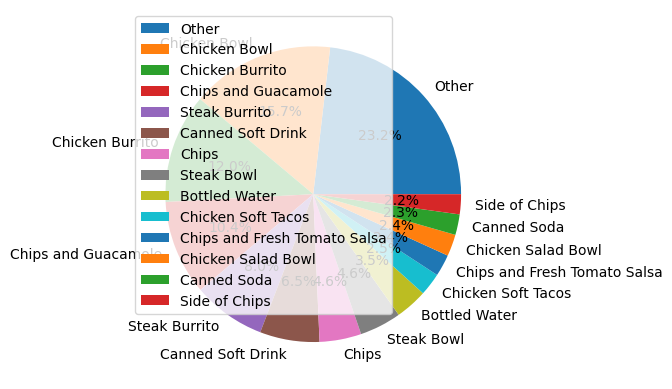

In [49]:
# let's find how many items of each type were purchased & build pie chart 
items = called.item_name.value_counts().to_frame().rename(columns={'count': 'bought'})

# i wanna find all items that were bought less then 100 times & group them into one group called `other`
less_100 = items['bought'] < 100 
less_100_total = items.loc[less_100].sum()
items = items.loc[~(less_100)]
items = pd.concat([
    items,
    pd.DataFrame([less_100_total.bought], index=['Other'], columns=['bought'])
]).sort_values('bought', ascending=False)

# then it's time to build a pie chart 
plt.pie(
    x=items.bought,
    labels=items.index, 
    autopct='%1.1f%%'
)
plt.legend()